In [1]:
!git clone https://github.com/Ar555Rathod/adaptive-trust-gate.git
%cd adaptive-trust-gate
!pip install -r requirements.txt

Cloning into 'adaptive-trust-gate'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 121 (delta 29), reused 118 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 10.25 MiB | 14.12 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/adaptive-trust-gate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.1 MB/s eta 0:00:00


In [3]:
!mkdir -p data/raw
!wget --no-check-certificate https://files.grouplens.org/datasets/movielens/ml-latest-small.zip -O data/raw/ml-latest-small.zip
!unzip -o data/raw/ml-latest-small.zip -d data/raw/

--2026-08-31 15:20:05--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
  Issued certificate has expired.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘data/raw/ml-latest-small.zip’

data/raw/ml-latest- 100%[===================>] 955.28K  2.67MB/s    in 0.3s    

2026-08-31 15:20:05 (2.67 MB/s) - ‘data/raw/ml-latest-small.zip’ saved [978202/978202]

Archive:  data/raw/ml-latest-small.zip
   creating: data/raw/ml-latest-small/
  inflating: data/raw/ml-latest-small/links.csv  
  inflating: data/raw/ml-latest-small/tags.csv  
  inflating: data/raw/ml-latest-small/ratings.csv  
  inflating: data/raw/ml-latest-small/README.txt  
  inflating: data/raw/ml-latest-small/movies.csv  


In [4]:
# Notice we use ATG_DATASET=movielens
!export ATG_DATASET=movielens && export PYTHONPATH=src && \
 python src/atg/data/normalize.py && \
 python scripts/01_build_splits.py && \
 python scripts/02_train_experts.py && \
 python scripts/03_static_hybrid.py && \
 python scripts/04_learned_gate.py && \
 python scripts/05_bandit_gate.py && \
 python scripts/06_ga_gate.py && \
 python scripts/07_sequential_gate.py && \
 python scripts/08_full_comparison.py && \
 python scripts/10_multiseed_full.py


Normalizing MovieLens data from /content/adaptive-trust-gate/data/raw/ml-latest-small...
Saved normalized data to /content/adaptive-trust-gate/data/processed/movielens
Total ratings: 100836
  train:  61676 (61.2%)
  val:    19545 (19.4%)
  test:   19615 (19.5%)

User sparsity segments (by TRAIN rating count):
segment
power    261
warm     257
cold      92
Name: count, dtype: int64

Saved splits to /content/adaptive-trust-gate/data/processed/movielens
Training CF expert (SVD++)...
  train_time_sec=46.48  n_params=311618

Training Content-Based expert...
  train_time_sec=0.12  n_params(repr size)=17350502
Saved fitted experts -> /content/adaptive-trust-gate/results/movielens/models

[CF/SVD++ [val]]
  overall  RMSE=0.9031  MAE=0.6960  n=19545
  cold     RMSE=0.9455  MAE=0.7324  n=6388
  warm     RMSE=0.9401  MAE=0.7222  n=1485
  power    RMSE=0.8741  MAE=0.6728  n=11672

[Content-Based [val]]
  overall  RMSE=1.0255  MAE=0.7801  n=19545
  cold     RMSE=1.2211  MAE=0.9194  n=6388
  warm   

In [5]:
import pandas as pd
import json

print("--- STATISTICAL SIGNIFICANCE (Model 3 vs Adaptive Gates) ---")
sig_df = pd.read_csv('results/movielens/metrics/full_comparison_significance.csv')
display(sig_df)

print("\n--- FULL COMPARISON TABLE (By Sparsity Segment) ---")
table_df = pd.read_csv('results/movielens/metrics/full_comparison_table.csv')
display(table_df)

print("\n--- MULTI-SEED ROBUSTNESS JSON ---")
with open('results/movielens/metrics/multiseed_full_comparison.json') as f:
    print(json.dumps(json.load(f), indent=2))


--- STATISTICAL SIGNIFICANCE (Model 3 vs Adaptive Gates) ---


,segment,model_a,model_b,rmse_a,rmse_b,mean_diff,ci_lo,ci_hi,bootstrap_significant,wilcoxon_p,wilcoxon_significant,n
0,overall,1_CF_SVDpp,2_ContentBased,0.938231,1.098874,-0.160626,-0.170270,-0.151302,True,5.674094e-163,True,19615
1,overall,1_CF_SVDpp,3_StaticHybrid,0.938231,0.939692,-0.001459,-0.003280,0.000353,False,7.578134e-03,True,19615
2,overall,1_CF_SVDpp,4_LearnedGate,0.938231,0.929298,0.008952,0.006574,0.011309,True,2.783291e-07,True,19615
3,overall,1_CF_SVDpp,5_BanditGate,0.938231,0.943022,-0.004797,-0.007519,-0.002097,True,1.601838e-01,False,19615
4,overall,1_CF_SVDpp,6_GAEvolvedGate,0.938231,0.932354,0.005885,0.003642,0.008155,True,1.979326e-04,True,19615
...,...,...,...,...,...,...,...,...,...,...,...,...
79,warm,4_LearnedGate,6_GAEvolvedGate,1.003560,1.003469,0.000030,-0.002379,0.002345,False,2.061922e-01,False,1502
80,warm,4_LearnedGate,7_SequentialGate,1.003560,1.003113,0.000477,-0.001445,0.002602,False,5.943257e-02,False,1502
81,warm,5_BanditGate,6_GAEvolvedGate,1.010027,1.003469,0.006469,0.000905,0.011846,True,1.655159e-04,True,1502
82,warm,5_BanditGate,7_SequentialGate,1.010027,1.003113,0.006916,0.001985,0.011847,True,7.468097e-04,True,1502



--- FULL COMPARISON TABLE (By Sparsity Segment) ---


,model,segment,rmse,mae,n,rank_spearman,rank_kendall,rank_n_users,rank_ndcg,rank_k,rank_arhr,rank_relevance_threshold,rank_roc_auc,rank_n
0,1_CF_SVDpp,overall,0.938231,0.723519,19615,0.274808,0.223143,588,0.903741,10,0.828266,4.0,0.732370,19615
1,1_CF_SVDpp,cold,1.010009,0.776719,6431,0.282462,0.223917,92,0.857105,10,0.794488,4.0,0.669459,6431
2,1_CF_SVDpp,warm,1.005602,0.760587,1502,0.277382,0.237270,239,0.956150,10,0.850976,4.0,0.734029,1502
3,1_CF_SVDpp,power,0.886824,0.689466,11682,0.269704,0.209663,257,0.868575,10,0.819239,4.0,0.759136,11682
4,2_ContentBased,overall,1.098874,0.833468,19615,0.080049,0.062751,588,0.884708,10,0.766066,4.0,0.649573,19615
5,2_ContentBased,cold,1.357344,1.024401,6431,-0.007675,-0.007696,92,0.806536,10,0.623262,4.0,0.539489,6431
6,2_ContentBased,warm,1.091017,0.831222,1502,0.019106,0.016583,239,0.944570,10,0.806276,4.0,0.666622,1502
7,2_ContentBased,power,0.927492,0.728647,11682,0.159776,0.124172,257,0.853318,10,0.779793,4.0,0.728353,11682
8,3_StaticHybrid,overall,0.939692,0.723851,19615,0.282191,0.229119,588,0.907302,10,0.834375,4.0,0.729733,19615
9,3_StaticHybrid,cold,1.032849,0.793302,6431,0.270309,0.212824,92,0.855383,10,0.776372,4.0,0.644221,6431



--- MULTI-SEED ROBUSTNESS JSON ---
{
  "seeds": [
    42,
    1,
    2,
    3,
    4
  ],
  "per_seed": {
    "1_CF_SVDpp": [
      {
        "overall": {
          "rmse": 0.9382309784306622,
          "mae": 0.7235186793257962,
          "n": 19615
        },
        "cold": {
          "rmse": 1.0100086006213485,
          "mae": 0.7767187121937658,
          "n": 6431
        },
        "power": {
          "rmse": 0.8868240846703029,
          "mae": 0.6894657625223285,
          "n": 11682
        },
        "warm": {
          "rmse": 1.0056020149050942,
          "mae": 0.7605870965855824,
          "n": 1502
        }
      },
      {
        "overall": {
          "rmse": 0.9372558682123683,
          "mae": 0.7230925400627897,
          "n": 18728
        },
        "cold": {
          "rmse": 1.0052915128416833,
          "mae": 0.7803659444532259,
          "n": 5171
        },
        "power": {
          "rmse": 0.900150943112892,
          "mae": 0.6951905335612624,
  

In [7]:
!export ATG_DATASET=movielens && export PYTHONPATH=src && python scripts/09_interpretability.py

Saved -> /content/adaptive-trust-gate/results/movielens/metrics/model4_gate_coefficients.png
Saved -> /content/adaptive-trust-gate/results/movielens/metrics/model4_g_vs_sparsity.png
Saved -> /content/adaptive-trust-gate/results/movielens/metrics/interpretability_vs_accuracy.png
Saved -> /content/adaptive-trust-gate/results/movielens/metrics/case_studies.csv

Case studies (high CF/CB disagreement, by segment):
 userId  itemId segment  train_rating_count  rating  pred__1_CF_SVDpp  pred__2_ContentBased  pred__3_StaticHybrid    g4  pred__4_LearnedGate    g6  pred__6_GAEvolvedGate    g7  used_fallback_7  pred__7_SequentialGate
      7     595    cold                   4     3.5             3.487                 0.500                 2.919 0.968                3.390 0.965                  3.382 0.810             True                   2.919
    496    7153    cold                   3     4.0             3.475                 1.000                 3.005 0.981                3.429 0.979       

1. Interpretability vs Accuracy (Model 4 vs Model 7):


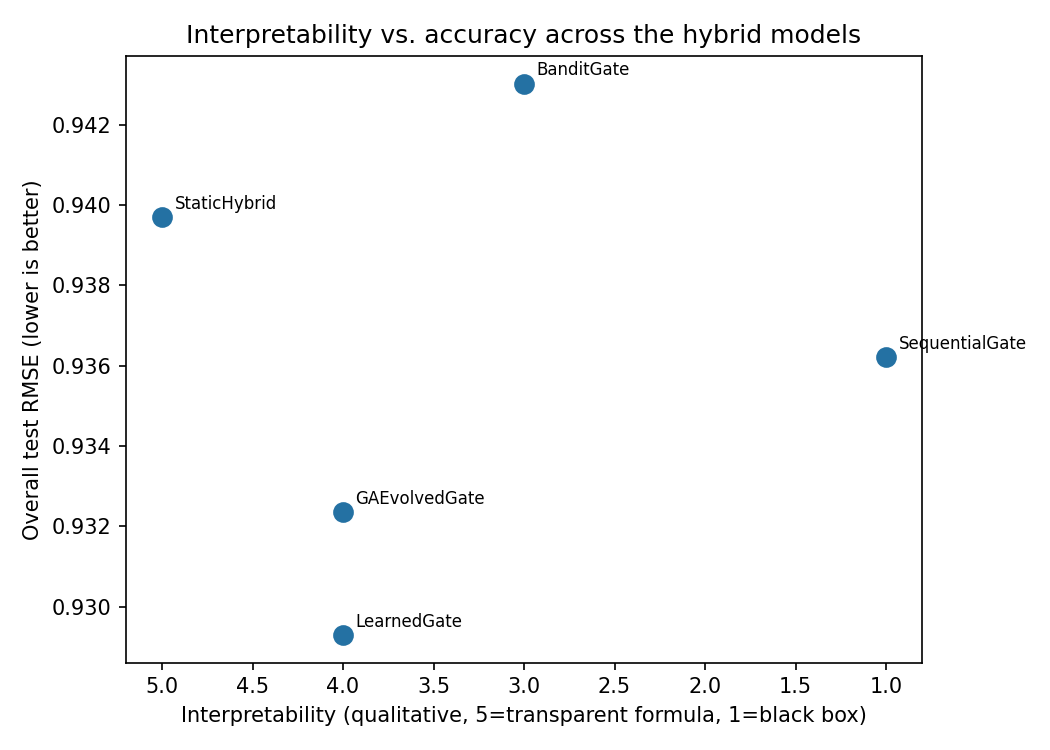


2. Bandit Gate Learning Curve:


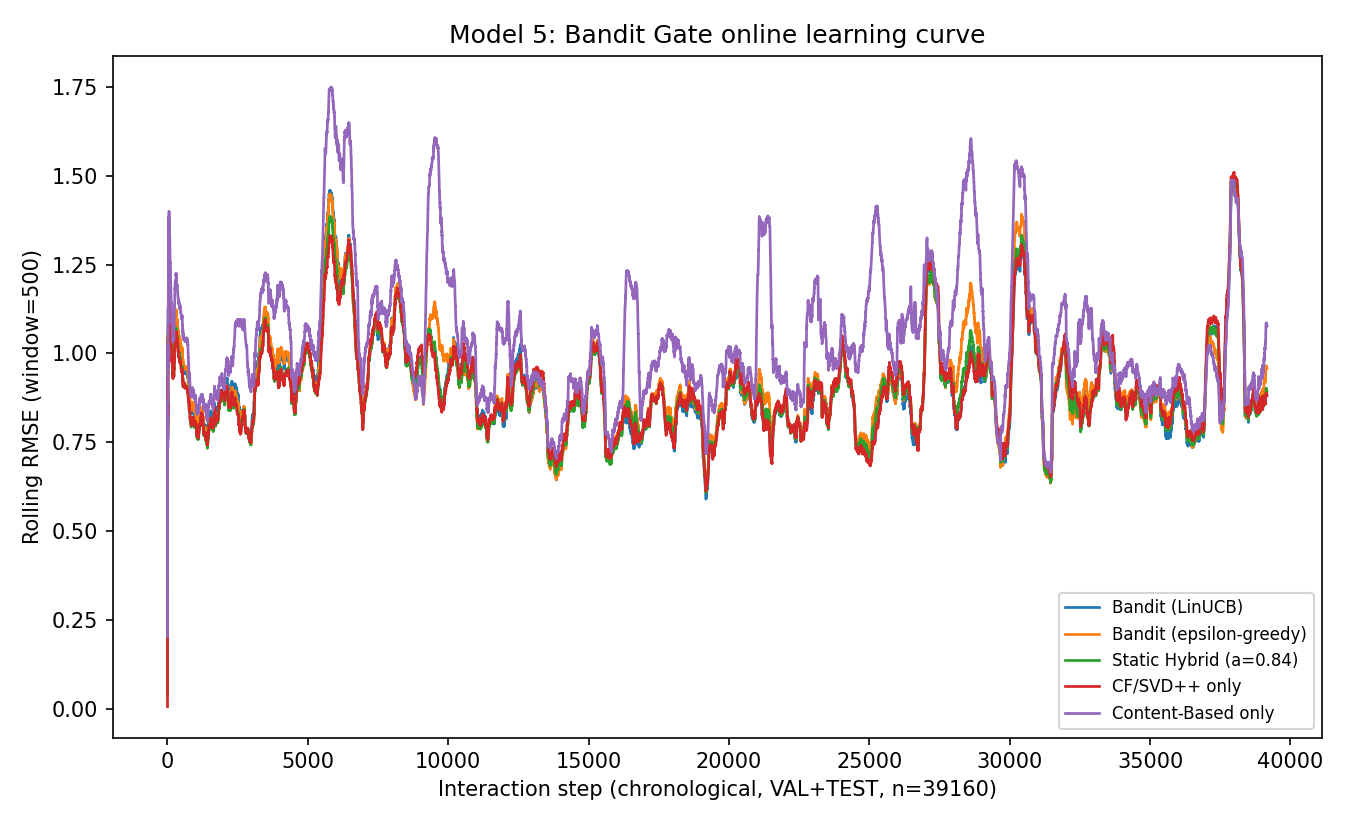


3. Genetic Algorithm Fitness Curve:


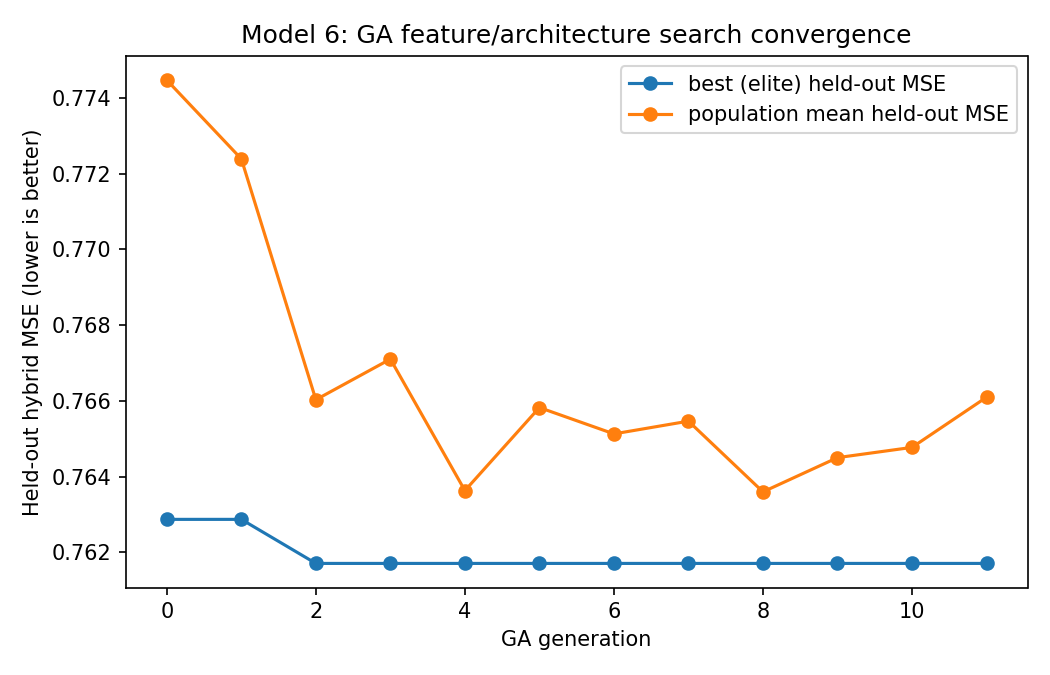


4. Learned Gate Trust vs User Sparsity:


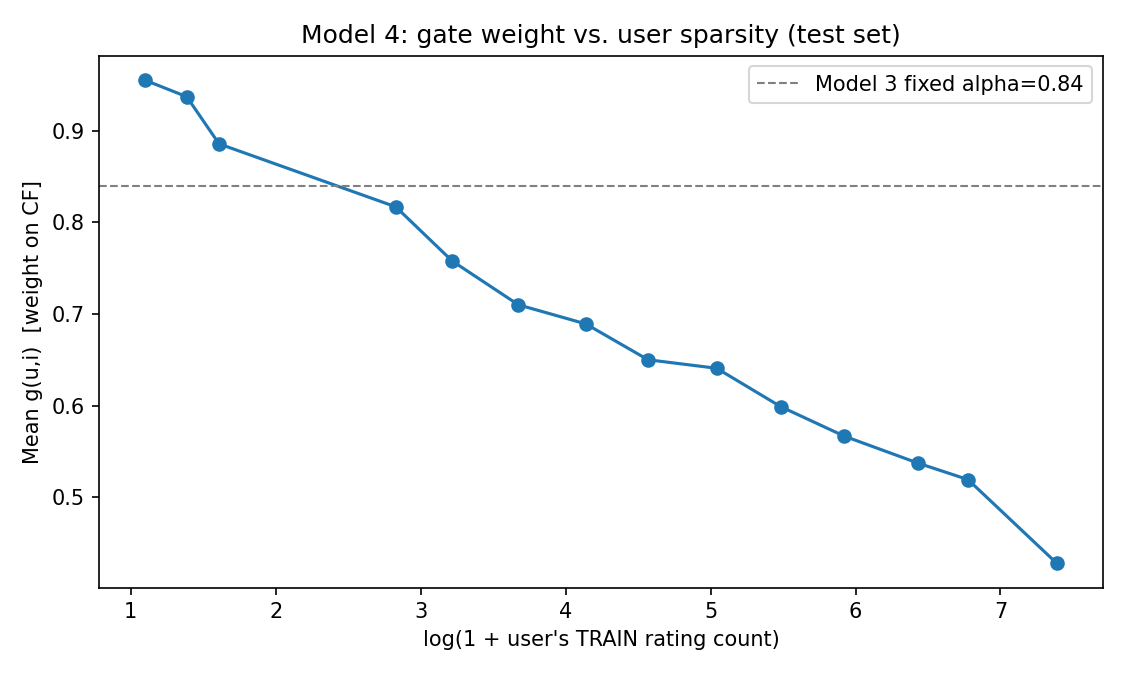

In [8]:
from IPython.display import Image, display

print("1. Interpretability vs Accuracy (Model 4 vs Model 7):")
display(Image('results/movielens/metrics/interpretability_vs_accuracy.png'))

print("\n2. Bandit Gate Learning Curve:")
display(Image('results/movielens/metrics/model5_learning_curve.png'))

print("\n3. Genetic Algorithm Fitness Curve:")
display(Image('results/movielens/metrics/model6_ga_fitness_curve.png'))

print("\n4. Learned Gate Trust vs User Sparsity:")
display(Image('results/movielens/metrics/model4_g_vs_sparsity.png'))
